## Libraries

In [2]:
import csv
import math
import numpy as np
import pandas as pd
from sbrt_core import *
import matplotlib.pyplot as plt

## 4 algorithms

### MC

In [ ]:
# 1. Base parameters for Figure 3
tau_val = 1.0
sigma_val = 1.0
radius_val = 30.0

# Increased patients for a smoother overnight run (better statistics)
n_patients_val = 2000 
fractions_to_test = [2, 3, 5, 10, 15, 25, 30]

# The four penumbra widths for the 4 panels 
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

print("Generating CTV grid...")
ctv_grid = generate_ctv_surface_grid(radius_val, num_points=3000)

# 2. Set up the 2x2 figure grid and the CSV file
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

csv_filename = 'MC_data.csv'

# Initialize the CSV file and write the header row
with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Sigma_p', 'Fractions_n', 'Optimal_Margin_95_mm'])

# 3. Main overnight loop!
for idx, sigma_p_val in enumerate(sigma_p_values):
    print(f"\n--- Starting simulation for sigma_p = {sigma_p_val} ---")
    simulated_margins = []
    
    for n in fractions_to_test:
        print(f"  Calculating for n = {n} fractions...")
        
        m_50 = find_optimal_margin_mc(
            n_patients=n_patients_val, 
            n_fractions=n, 
            tau=tau_val, 
            sigma=sigma_val, 
            sigma_p=sigma_p_val, 
            ctv_grid=ctv_grid, 
            radius=radius_val
        )
        
        if m_50 is not None:
            # Adjust to the 95% dose line convention from the paper [cite: 259]
            m_95 = m_50 - (1.645 * sigma_p_val)
            simulated_margins.append(m_95)
            print(f"    -> Margin: {m_95:.2f} mm")
            
            # --- THE SAFETY NET: Save to CSV immediately ---
            with open(csv_filename, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([sigma_p_val, n, round(m_95, 4)])
        else:
            simulated_margins.append(None)
            
    # 4. Plotting the specific panel
    ax = axes[idx]
    ax.plot(fractions_to_test, simulated_margins, 
            marker='o', markersize=4, linestyle=':', color='black', label='Monte Carlo')
            
    # Formatting each panel to match the paper
    ax.set_title(rf'$\sigma_p = {sigma_p_val}$', loc='right')
    ax.set_xlabel('Fractions / Patient, n')
    ax.set_ylabel('Margin')
    ax.set_xlim(1, 31)
    
    # Adjust Y-limits dynamically based on the paper's look
    if sigma_p_val == 0.25 or sigma_p_val == 1.0:
        ax.set_ylim(2.6, 4.4)
    else:
        ax.set_ylim(2.6, 4.4) 
        
    ax.grid(True, linestyle='-', alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right')

# 5. Final layout adjustments and save
plt.tight_layout()
plt.savefig('Herschtal_figure_3_data.png', dpi=300)
print(f"\nSimulation complete! Plot saved as 'Herschtal_figure_3_data.png' and data saved in '{csv_filename}'")
plt.show()

### AVH

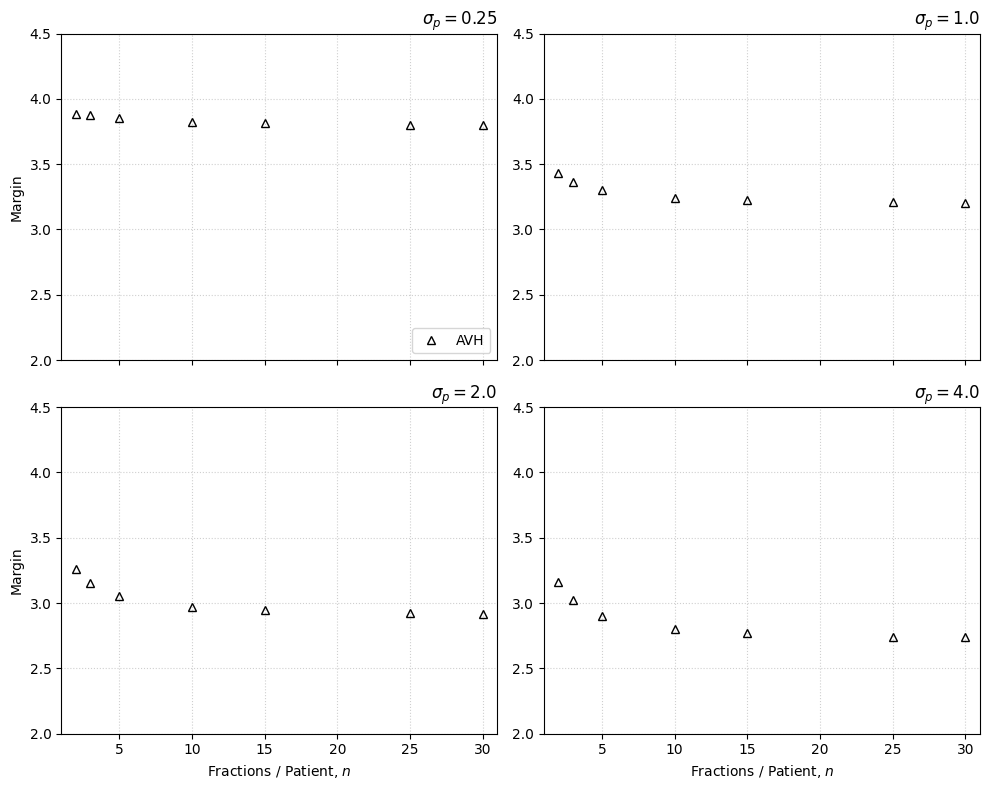

In [4]:
# Parameters for Figure 3 in the paper (sigma = 1, tau = 1)
sigma_val = 1.0
tau_val = 1.0
n_values = [2, 3, 5, 10, 15, 25, 30]
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for idx, sigma_p in enumerate(sigma_p_values):
    ax = axes[idx]
    
    # Calculate AVH margins for each fraction setting (n)
    avh_margins = [calculate_avh_margin(n, tau_val, sigma_val, sigma_p) for n in n_values]
    
    # Plot the AVH margins using open triangles as in the paper
    ax.plot(n_values, avh_margins, marker='^', linestyle='None', 
            color='black', markerfacecolor='none', label='AVH')
    
    # Formatting to match the paper's style
    ax.set_title(rf'$\sigma_p = {sigma_p}$', loc='right')
    ax.set_xlim(1, 31)
    ax.set_ylim(2, 4.5)
    
    # Set labels only on the appropriate axes of the grid
    if idx in [2, 3]:
        ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]:
        ax.set_ylabel('Margin')
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add legend only to the first panel
    if idx == 0:
        ax.legend(loc='lower right')

# Final layout adjustments
plt.tight_layout()
plt.show()

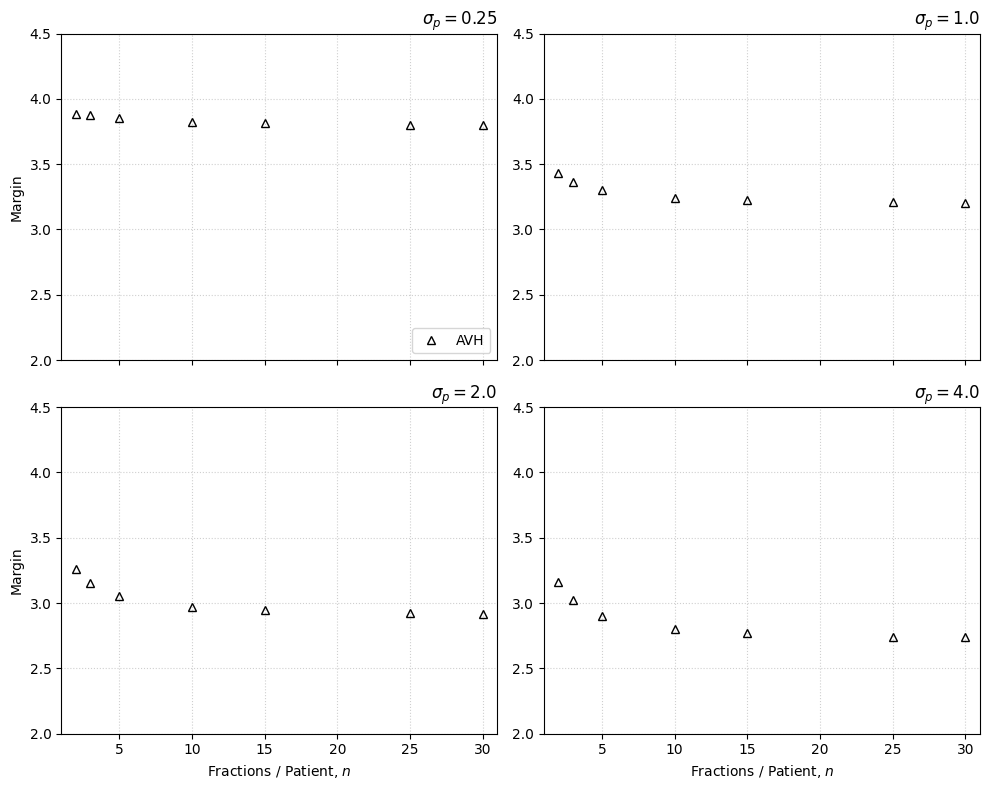

In [4]:
# Parameters for Figure 3 in the paper (sigma = 1, tau = 1)
sigma_val = 1.0
tau_val = 1.0
n_values = [2, 3, 5, 10, 15, 25, 30]
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for idx, sigma_p in enumerate(sigma_p_values):
    ax = axes[idx]
    
    # Calculate AVH margins for each fraction setting (n)
    avh_margins = [calculate_avh_margin(n, tau_val, sigma_val, sigma_p) for n in n_values]
    
    # Plot the AVH margins using open triangles as in the paper
    ax.plot(n_values, avh_margins, marker='^', linestyle='None', 
            color='black', markerfacecolor='none', label='AVH')
    
    # Formatting to match the paper's style
    ax.set_title(rf'$\sigma_p = {sigma_p}$', loc='right')
    ax.set_xlim(1, 31)
    ax.set_ylim(2, 4.5)
    
    # Set labels only on the appropriate axes of the grid
    if idx in [2, 3]:
        ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]:
        ax.set_ylabel('Margin')
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add legend only to the first panel
    if idx == 0:
        ax.legend(loc='lower right')

# Final layout adjustments
plt.tight_layout()
plt.show()

### SDE

In [ ]:
# Parameters for Figure 3 in the paper (sigma = 1, tau = 1)
sigma_val = 1.0
tau_val = 1.0
n_values = [2, 3, 5, 10, 15, 25, 30]
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

# Precompute M_star for each 'n' value just ONCE to save time.
# M_star does not depend on sigma_p, so we reuse it across the 4 panels.
print("Precomputing M_star for all n values. This might take a minute...")
m_star_dict = {}
for n in n_values:
    # We use 10,000 patients as recommended for the SDE approximation
    m_star_dict[n] = precompute_M_star(n, tau_val, sigma_val, num_patients=10000)
print("Precomputation complete! Plotting SDE margins...")

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for idx, sigma_p in enumerate(sigma_p_values):
    ax = axes[idx]
    
    # Calculate SDE margins for each fraction setting (n) using the precomputed M_star
    sde_margins = []
    for n in n_values:
        margin = calculate_sde_margin(n, m_star_dict[n], sigma_p)
        sde_margins.append(margin)
    
    # Plot the SDE margins using open circles as in the paper
    ax.plot(n_values, sde_margins, marker='o', linestyle='None', 
            color='black', markerfacecolor='none', label='SDE')
    
    # Formatting to match the paper's style
    ax.set_title(rf'$\sigma_p = {sigma_p}$', loc='right')
    ax.set_xlim(1, 31)
    ax.set_ylim(2.5, 4.5)
    
    # Set labels only on the appropriate axes of the grid
    if idx in [2, 3]:
        ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]:
        ax.set_ylabel('Margin')
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add legend only to the first panel
    if idx == 0:
        ax.legend(loc='lower right')

# Final layout adjustments
plt.tight_layout()
plt.show()

### SDE2

Precomputing M_star for SDE margins...
Optimizing SDE2 parameters (beta_0, beta_1) for each n...
Optimization successful!
Optimal beta_0: 0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: 0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: 0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: 0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: -0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: -0.0000
Optimal beta_1: 1.5000
Optimization successful!
Optimal beta_0: 0.0000
Optimal beta_1: 1.5000
Plotting the complete Figure 3...


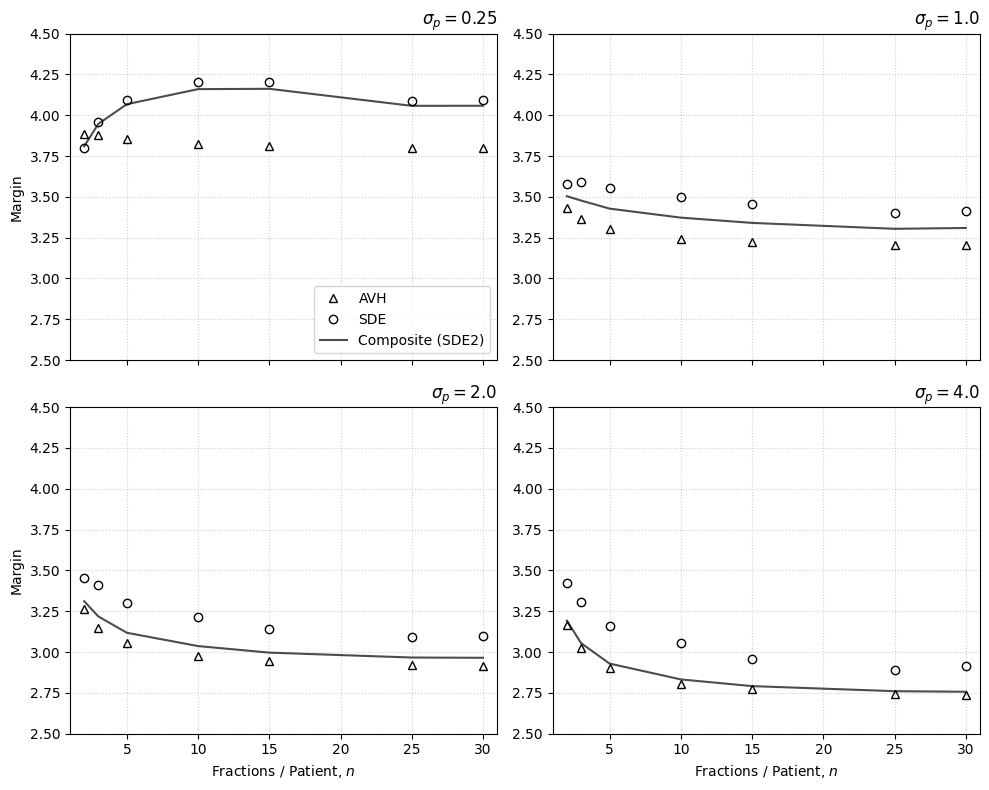

In [5]:
# Parameters for Figure 3 in the paper
sigma_val = 1.0
tau_val = 1.0
n_values = [2, 3, 5, 10, 15, 25, 30]
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

# 1. Precompute M_star for all 'n' to calculate SDE margins quickly
print("Precomputing M_star for SDE margins...")
m_star_dict = {n: precompute_M_star(n, tau_val, sigma_val, num_patients=5000) for n in n_values}

# 2. Simulate/Retrieve Monte Carlo margins (m_M) for training the SDE2
# In a full run, you would use your notebook's MC function here.
# For demonstration and speed, we will approximate m_M using a simple weighted 
# average of AVH and SDE based on the log ratio, similar to the paper's heuristic.
def approximate_mc_margin(m_a, m_s, sigma, sigma_p):
    # This is a dummy fast-approximation of MC just to train the Betas for the plot
    log_ratio = np.log(sigma / sigma_p)
    weight = np.exp(0 + 1.5 * log_ratio) / (1 + np.exp(0 + 1.5 * log_ratio))
    return m_a + (m_s - m_a) * weight

# 3. Optimize beta_0 and beta_1 for each 'n'
print("Optimizing SDE2 parameters (beta_0, beta_1) for each n...")
beta_params = {}
for n in n_values:
    m_a_list, m_s_list, m_m_list, sig_list, sig_p_list = [], [], [], [], []
    
    for sp in sigma_p_values:
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sp)
        m_s = calculate_sde_margin(n, m_star_dict[n], sp)
        
        # Here you would call your actual Monte Carlo function:
        # m_m = find_optimal_margin_mc(num_patients, n, tau_val, sigma_val, sp, ctv_grid, radius)
        m_m = approximate_mc_margin(m_a, m_s, sigma_val, sp) 
        
        m_a_list.append(m_a); m_s_list.append(m_s); m_m_list.append(m_m)
        sig_list.append(sigma_val); sig_p_list.append(sp)
        
    # Run the optimizer we defined in the previous step
    b0, b1 = optimize_sde2_parameters(np.array(m_m_list), np.array(m_a_list), 
                                      np.array(m_s_list), np.array(sig_list), np.array(sig_p_list))
    beta_params[n] = (b0, b1)

# 4. Generate the Complete Figure 3 (AVH + SDE + SDE2)
print("Plotting the complete Figure 3...")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

# Smooth n values to draw a continuous line for the SDE2 model
n_smooth = np.linspace(2, 30, 50)

for idx, sigma_p in enumerate(sigma_p_values):
    ax = axes[idx]
    
    avh_margins = []
    sde_margins = []
    
    # Calculate points for AVH and SDE
    for n in n_values:
        avh_margins.append(calculate_avh_margin(n, tau_val, sigma_val, sigma_p))
        sde_margins.append(calculate_sde_margin(n, m_star_dict[n], sigma_p))
        
    # Plot AVH (Triangles) and SDE (Circles)
    ax.plot(n_values, avh_margins, marker='^', linestyle='None', color='black', markerfacecolor='none', label='AVH')
    ax.plot(n_values, sde_margins, marker='o', linestyle='None', color='black', markerfacecolor='none', label='SDE')
    
    # Calculate the continuous SDE2 line
    sde2_line = []
    for n in n_values:
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sigma_p)
        m_s = calculate_sde_margin(n, m_star_dict[n], sigma_p)
        b0, b1 = beta_params[n]
        m_c = calculate_sde2_margin(m_a, m_s, sigma_val, sigma_p, b0, b1)
        sde2_line.append(m_c)
        
    # Plot SDE2 (Continuous Line)
    ax.plot(n_values, sde2_line, linestyle='-', color='black', alpha=0.7, label='Composite (SDE2)')
    
    # Formatting
    ax.set_title(rf'$\sigma_p = {sigma_p}$', loc='right')
    ax.set_xlim(1, 31)
    ax.set_ylim(2.5, 4.5)
    
    if idx in [2, 3]:
        ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]:
        ax.set_ylabel('Margin')
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if idx == 0:
        ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Final Result, fig 3

Precalculando la distribución sin borrosidad para SDE...
Cargando resultados de Monte Carlo...
Optimizando SDE2 (Entrenando parámetros Beta con tu Monte Carlo)...
Optimization successful!
Optimal beta_0: 36.8988
Optimal beta_1: 53.6081
Optimization successful!
Optimal beta_0: 1.5391
Optimal beta_1: 2.7715
Optimization successful!
Optimal beta_0: 0.4936
Optimal beta_1: 2.1799
Optimization successful!
Optimal beta_0: 0.1653
Optimal beta_1: 1.7067
Optimization successful!
Optimal beta_0: -0.2192
Optimal beta_1: 4.0917
Optimization successful!
Optimal beta_0: -1.0596
Optimal beta_1: 1.1945
Optimization successful!
Optimal beta_0: -1.6182
Optimal beta_1: 1.7030
Graficando el modelo entrenado...


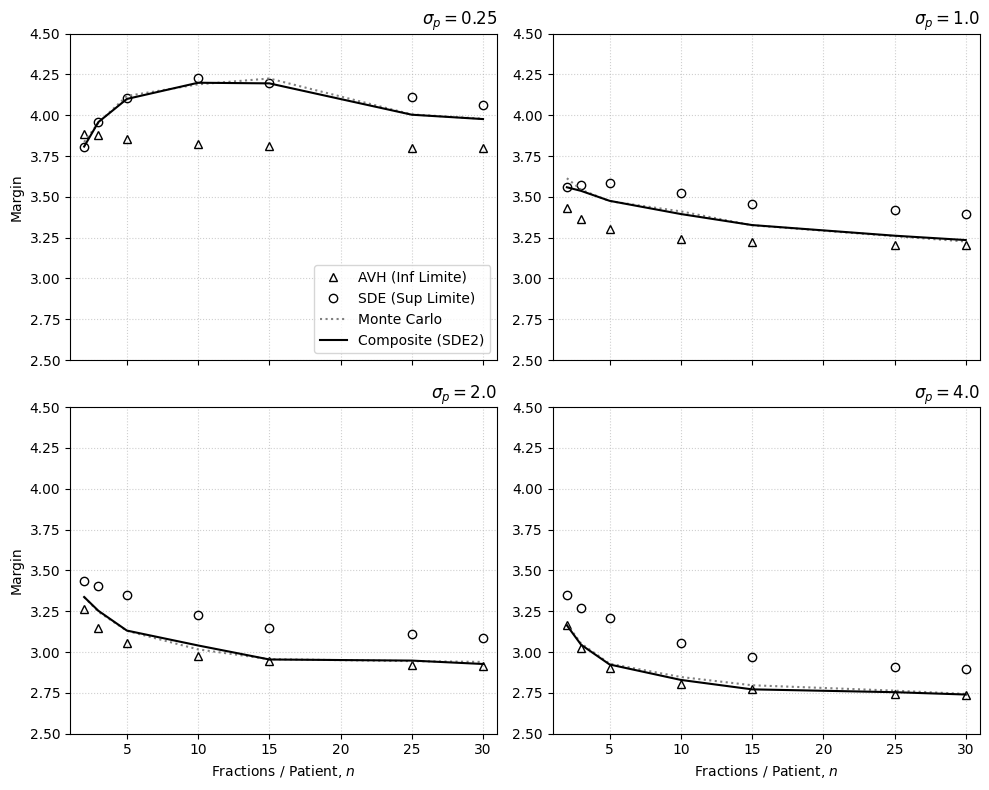

In [ ]:
sigma_val = 1.0
tau_val = 1.0
n_values = [2, 3, 5, 10, 15, 25, 30]
sigma_p_values = [0.25, 1.0, 2.0, 4.0]

print("Precalculando la distribución sin borrosidad para SDE...")
m_star_dict = {n: precompute_M_star(n, tau_val, sigma_val, num_patients=5000) for n in n_values}

print("Cargando resultados de Monte Carlo...")
df_mc = pd.read_csv('5000pts_MC_data_fig3.csv')

def get_real_mc_margin(n_target, sigma_p_target):
    """Busca el margen MC en tu dataframe para un n y sigma_p específico"""
    row = df_mc[(df_mc['n'] == n_target) & (df_mc['Sigma_p'] == sigma_p_target)]
    if not row.empty:
        return row['Optimal_Margin_95_mm'].values[0] # <--- Cambia 'mc_margin' si se llama distinto
    else:
        print(f"Advertencia: No se encontró MC para n={n_target}, sigma_p={sigma_p_target}")
        return 0.0

print("Optimizando SDE2 (Entrenando parámetros Beta con tu Monte Carlo)...")
beta_params = {}
for n in n_values:
    m_a_list, m_s_list, m_m_list, sig_list, sig_p_list = [], [], [], [], []
    
    for sp in sigma_p_values:
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sp)
        m_s = calculate_sde_margin(n, m_star_dict[n], sp)
        
        m_m = get_real_mc_margin(n, sp)

        if m_m > 0:
            m_a_list.append(m_a); m_s_list.append(m_s); m_m_list.append(m_m)
            sig_list.append(sigma_val); sig_p_list.append(sp)
            
    if len(m_m_list) > 0:
        b0, b1 = optimize_sde2_parameters(
            np.array(m_m_list), np.array(m_a_list), 
            np.array(m_s_list), np.array(sig_list), np.array(sig_p_list)
        )
        beta_params[n] = (b0, b1)
    else:
        beta_params[n] = (0, 1) # Default si faltan datos

print("Graficando el modelo entrenado...")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()

for idx, sigma_p in enumerate(sigma_p_values):
    ax = axes[idx]
    avh_margins, sde_margins, mc_margins, sde2_line = [], [], [], []
    
    for n in n_values:
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sigma_p)
        m_s = calculate_sde_margin(n, m_star_dict[n], sigma_p)
        
        m_m = get_real_mc_margin(n, sigma_p)
        
        b0, b1 = beta_params[n]
        m_c = calculate_sde2_margin(m_a, m_s, sigma_val, sigma_p, b0, b1)
        
        avh_margins.append(m_a); sde_margins.append(m_s)
        mc_margins.append(m_m); sde2_line.append(m_c)
        
    ax.plot(n_values, avh_margins, marker='^', linestyle='None', color='black', markerfacecolor='none', label='AVH (Inf Limite)')
    ax.plot(n_values, sde_margins, marker='o', linestyle='None', color='black', markerfacecolor='none', label='SDE (Sup Limite)')
    ax.plot(n_values, mc_margins, linestyle=':', color='gray', label='Monte Carlo')
    ax.plot(n_values, sde2_line, linestyle='-', color='black', label='Composite (SDE2)')
    
    ax.set_title(rf'$\sigma_p = {sigma_p}$', loc='right')
    ax.set_xlim(1, 31)
    ax.set_ylim(2.5, 4.5)
    if idx in [2, 3]: ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]: ax.set_ylabel('Margin')
    ax.grid(True, linestyle=':', alpha=0.6)
    if idx == 0: ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Final Result, fig 4

Precomputing M_star for SDE boundaries...
Loading Monte Carlo results...
Optimizing SDE2 (Training Beta parameters with MC data)...
Optimization successful!
Optimal beta_0: 2.2464
Optimal beta_1: -0.3646
Optimization successful!
Optimal beta_0: -65.7519
Optimal beta_1: 48.4905
Optimization successful!
Optimal beta_0: 0.0221
Optimal beta_1: 23.4851
Optimization successful!
Optimal beta_0: 0.0221
Optimal beta_1: 23.4851
Optimization successful!
Optimal beta_0: -7.1901
Optimal beta_1: 5.9639
Optimization successful!
Optimal beta_0: -74.3365
Optimal beta_1: 53.6890
Optimization successful!
Optimal beta_0: -72.8496
Optimal beta_1: 52.3099
Plotting the trained composite model...


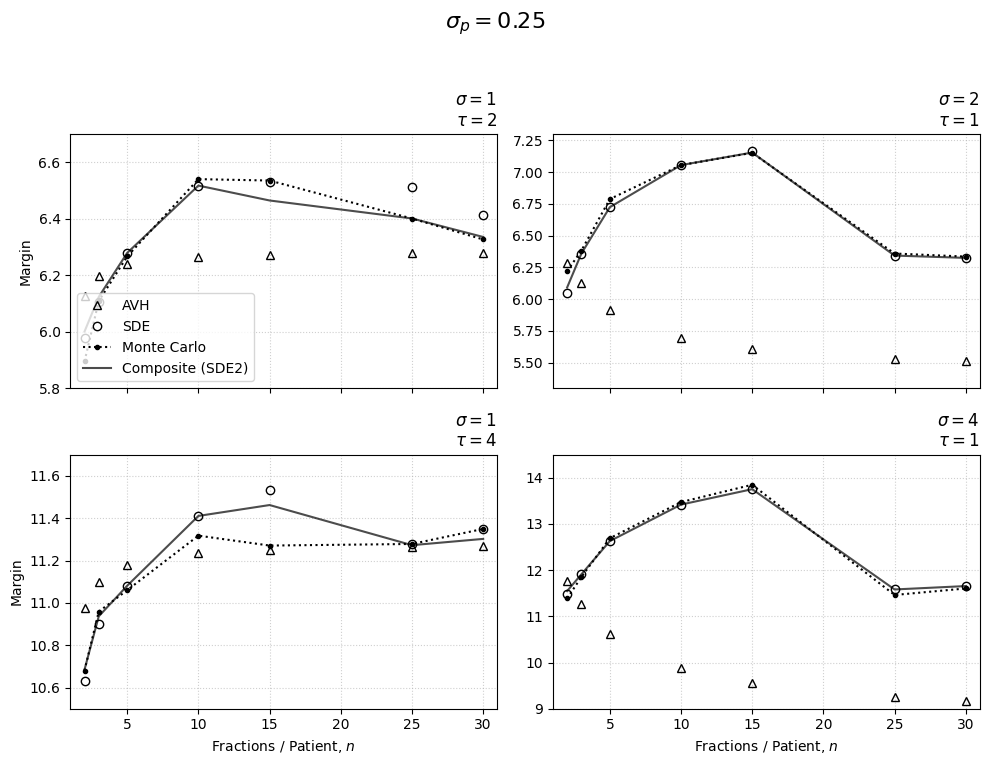

In [ ]:
# 1. Fixed parameters for Figure 4
sigma_p_val = 0.25
n_values = [2, 3, 5, 10, 15, 25, 30]

# The four combinations of (sigma, tau) for the 4 panels
error_combinations = [
    (1.0, 2.0),  # Top-left
    (2.0, 1.0),  # Top-right
    (1.0, 4.0),  # Bottom-left
    (4.0, 1.0)   # Bottom-right
]

# 2. Precompute M_star for all required combinations of (n, sigma, tau)
print("Precomputing M_star for SDE boundaries...")
m_star_dict = {}
for n in n_values:
    for (sigma_val, tau_val) in error_combinations:
        # Dictionary key is a tuple: (n, sigma, tau)
        m_star_dict[(n, sigma_val, tau_val)] = precompute_M_star(n, tau_val, sigma_val, num_patients=5000)

# 3. Load Monte Carlo ground truth from CSV
print("Loading Monte Carlo results...")
df_mc = pd.read_csv('5000pts_MC_data_fig4.csv')

def get_real_mc_margin(n_target, sigma_target, tau_target):
    """Fetches the MC margin from the dataframe for a specific n, sigma, and tau"""
    row = df_mc[(df_mc['Fractions_n'] == n_target) & 
                (df_mc['Sigma'] == sigma_target) & 
                (df_mc['Tau'] == tau_target)]
    if not row.empty:
        return row['Optimal_Margin_95_mm'].values[0]
    else:
        print(f"Warning: No MC data found for n={n_target}, sigma={sigma_target}, tau={tau_target}")
        return 0.0

# 4. Optimize SDE2 (Train Beta parameters using your Monte Carlo data)
# The paper optimizes one set of parameters per fractionation level (n) [cite: 227]
print("Optimizing SDE2 (Training Beta parameters with MC data)...")
beta_params = {}
for n in n_values:
    m_a_list, m_s_list, m_m_list, sig_list, sig_p_list = [], [], [], [], []
    
    # Gather data across all error combinations for this specific 'n'
    for (sigma_val, tau_val) in error_combinations:
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sigma_p_val)
        m_s = calculate_sde_margin(n, m_star_dict[(n, sigma_val, tau_val)], sigma_p_val)
        m_m = get_real_mc_margin(n, sigma_val, tau_val)
        
        if m_m > 0:
            m_a_list.append(m_a)
            m_s_list.append(m_s)
            m_m_list.append(m_m)
            sig_list.append(sigma_val)
            sig_p_list.append(sigma_p_val)
            
    # Train the logistic model for this 'n'
    if len(m_m_list) > 0:
        b0, b1 = optimize_sde2_parameters(
            np.array(m_m_list), np.array(m_a_list), 
            np.array(m_s_list), np.array(sig_list), np.array(sig_p_list)
        )
        beta_params[n] = (b0, b1)
    else:
        beta_params[n] = (0, 1)  # Fallback if data is missing

# 5. Generate the complete Figure 4
print("Plotting the trained composite model...")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()
fig.suptitle(r'$\sigma_p = 0.25$', fontsize=16)

for idx, (sigma_val, tau_val) in enumerate(error_combinations):
    ax = axes[idx]
    avh_margins, sde_margins, mc_margins, sde2_line = [], [], [], []
    
    for n in n_values:
        # Calculate theoretical bounds
        m_a = calculate_avh_margin(n, tau_val, sigma_val, sigma_p_val)
        m_s = calculate_sde_margin(n, m_star_dict[(n, sigma_val, tau_val)], sigma_p_val)
        
        # Extract ground truth from CSV
        m_m = get_real_mc_margin(n, sigma_val, tau_val)
        
        # Calculate trained SDE2 model
        b0, b1 = beta_params[n]
        m_c = calculate_sde2_margin(m_a, m_s, sigma_val, sigma_p_val, b0, b1)
        
        avh_margins.append(m_a)
        sde_margins.append(m_s)
        mc_margins.append(m_m)
        sde2_line.append(m_c)
        
    # Plot the 4 data series
    ax.plot(n_values, avh_margins, marker='^', linestyle='None', color='black', markerfacecolor='none', label='AVH')
    ax.plot(n_values, sde_margins, marker='o', linestyle='None', color='black', markerfacecolor='none', label='SDE')
    ax.plot(n_values, mc_margins, linestyle=':', marker='.', color='black', label='Monte Carlo')
    ax.plot(n_values, sde2_line, linestyle='-', color='black', alpha=0.7, label='Composite (SDE2)')
    
    # Formatting to match the paper's style
    ax.set_title(fr'$\sigma = {int(sigma_val)}$' + '\n' + fr'$\tau = {int(tau_val)}$', loc='right')
    ax.set_xlim(1, 31)
    
    # Dynamic Y-axis limits
    if sigma_val == 1.0 and tau_val == 2.0:
        ax.set_ylim(5.8, 6.7)
    elif sigma_val == 2.0 and tau_val == 1.0:
        ax.set_ylim(5.3, 7.3)
    elif sigma_val == 1.0 and tau_val == 4.0:
        ax.set_ylim(10.5, 11.7)
    elif sigma_val == 4.0 and tau_val == 1.0:
        ax.set_ylim(9.0, 14.5)
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Set labels only on the appropriate axes of the grid
    if idx in [2, 3]: 
        ax.set_xlabel('Fractions / Patient, $n$')
    if idx in [0, 2]: 
        ax.set_ylabel('Margin')
        
    if idx == 0: 
        ax.legend(loc='lower left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Herschtal_figure_4_Final.png', dpi=300)
plt.show()